Dataset Loaded Successfully

First 5 rows:


,Date,Product,Location,Units_Sold,Price,Revenue
0,2024-01-01,Dark,Ballari,120,50,6000
1,2024-01-02,Milk,Bengaluru,150,40,6000
2,2024-01-03,White,Mysuru,100,45,4500
3,2024-01-04,Truffle,Hubballi,80,60,4800
4,2024-01-05,Bar,Ballari,200,30,6000



Columns:
Index(['Date', 'Product', 'Location', 'Units_Sold', 'Price', 'Revenue'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        15 non-null     object
 1   Product     15 non-null     object
 2   Location    15 non-null     object
 3   Units_Sold  15 non-null     int64 
 4   Price       15 non-null     int64 
 5   Revenue     15 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 848.0+ bytes

Missing Values:
Date          0
Product       0
Location      0
Units_Sold    0
Price         0
Revenue       0
dtype: int64

After cleaning shape: (15, 6)


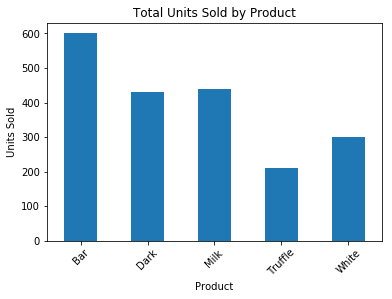


Model Trained Successfully

Model Performance:
Mean Squared Error: 174.59381460893724
R2 Score: 0.8712012843048824


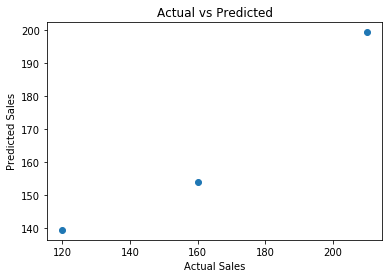

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline


data = pd.read_excel("C:/Users/hp5cd/OneDrive/Desktop/chocolate_sales.xlsx")

print("Dataset Loaded Successfully")

print("\nFirst 5 rows:")
display(data.head())

print("\nColumns:")
print(data.columns)

print("\nDataset Info:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())


data = data.dropna()

print("\nAfter cleaning shape:", data.shape)


if 'Product' in data.columns and 'Units_Sold' in data.columns:
    
    product_sales = data.groupby('Product')['Units_Sold'].sum()

    plt.figure()
    product_sales.plot(kind='bar')
    plt.title("Total Units Sold by Product")
    plt.xlabel("Product")
    plt.ylabel("Units Sold")
    plt.xticks(rotation=45)
    plt.show()

else:
    print("Required columns not found")


data_encoded = data.copy()
le = LabelEncoder()

for col in data_encoded.select_dtypes(include='object').columns:
    data_encoded[col] = le.fit_transform(data_encoded[col])


if 'Units_Sold' in data_encoded.columns:
    X = data_encoded.drop('Units_Sold', axis=1)
    y = data_encoded['Units_Sold']
else:
    raise ValueError("Units_Sold column not found")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully")

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

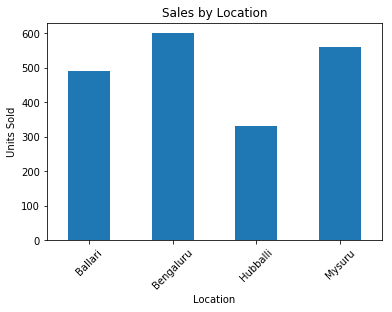

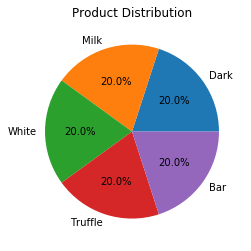

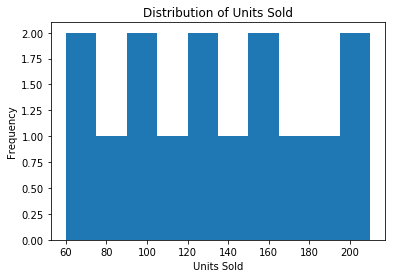

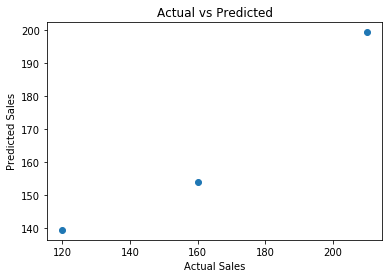

In [5]:
if 'Location' in data.columns and 'Units_Sold' in data.columns:
    location_sales = data.groupby('Location')['Units_Sold'].sum()

    plt.figure()
    location_sales.plot(kind='bar')
    plt.title("Sales by Location")
    plt.xlabel("Location")
    plt.ylabel("Units Sold")
    plt.xticks(rotation=45)
    plt.show()


if 'Product' in data.columns:
    product_count = data['Product'].value_counts()

    plt.figure()
    product_count.plot(kind='pie', autopct='%1.1f%%')
    plt.title("Product Distribution")
    plt.ylabel("")
    plt.show()


if 'Units_Sold' in data.columns:
    plt.figure()
    plt.hist(data['Units_Sold'], bins=10)
    plt.title("Distribution of Units Sold")
    plt.xlabel("Units Sold")
    plt.ylabel("Frequency")
    plt.show()


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [8]:
print("SALES REPORT")

total_sales = data['Units_Sold'].sum()
total_revenue = data['Revenue'].sum()

print("\nTotal Units Sold:", total_sales)
print("Total Revenue:", total_revenue)

print("\nSales by Product:")
print(data.groupby('Product')['Units_Sold'].sum())

print("\nSales by Location:")
print(data.groupby('Location')['Units_Sold'].sum())


print("\nBUSINESS INSIGHTS")

best_product = data.groupby('Product')['Units_Sold'].sum().idxmax()
print("\nBest Selling Product:", best_product)

best_location = data.groupby('Location')['Units_Sold'].sum().idxmax()
print("Best Performing Location:", best_location)


print("\nSUGGESTIONS")

print("- Increase production of high-demand products")
print("- Focus marketing in high-performing locations")
print("- Adjust pricing strategies to improve sales")

SALES REPORT

Total Units Sold: 1980
Total Revenue: 83200

Sales by Product:
Product
Bar        600
Dark       430
Milk       440
Truffle    210
White      300
Name: Units_Sold, dtype: int64

Sales by Location:
Location
Ballari      490
Bengaluru    600
Hubballi     330
Mysuru       560
Name: Units_Sold, dtype: int64

BUSINESS INSIGHTS

Best Selling Product: Bar
Best Performing Location: Bengaluru

SUGGESTIONS
- Increase production of high-demand products
- Focus marketing in high-performing locations
- Adjust pricing strategies to improve sales
